In [28]:
import os
import sys
import json
import numpy as np
import pandas as pd
from glob import glob
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from dtwalign import dtw
from tslearn.metrics import SoftDTW, soft_dtw
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

sys.path.append("/Users/christina/code/RockPaperScissors_backup/modules")
from utils import get_video_metadata, get_cropped_video_indices, load_splits_cropped, ALIGN_DIR
from get_frames import get_video_csv, get_frame_landmarks

#from tslearn.metrics import SoftDTW
#from tslearn.metrics.soft_dtw import _soft_dtw_alignment
from scipy.spatial.distance import cdist
from sklearn.metrics import confusion_matrix
from tslearn import metrics

In [29]:
BASE_DIR = "/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2"
CSV_FILE_NAME = "img_landmarks_norm_v14"
COORD_TYPES = ['m', 'norm', 'scaled', 'rotated']      
PLOTS_DIR = "./outputs/dtw/"
CREATE_PLOTS = False
DTW_VARS = ['OpenEndDTW', 'SoftDTW']
#DTW_VARS = ['CTW']
DTW_COLORS = {'OpenEndDTW': 'blue', 'SoftDTW': '#08D337', 'CTW': 'orange'}



### Utils

In [ ]:
def accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return float(np.mean(y_true == y_pred))

def pad_landmark_frames_to_match_video_frames(
    landmarks, mp_idx, real_idx, action_onset_frame
) -> np.ndarray:
    """Pad a landmarks array so its first axis aligns with real_idx.

    For each frame in `real_idx` missing from `mp_idx`, this function inserts a copy
    of the *next* available landmark row. If the missing frame lies after the last
    mp_idx, it copies the previous available row instead.

    Args:
        landmarks: np.ndarray of shape (M, L, 3) where M == len(mp_idx)
        mp_idx: sequence of M increasing frame indices where landmarks were detected
        real_idx: sequence of N increasing frame indices representing real video frames

    Returns:
        np.ndarray of shape (N, L, 3) where rows corresponding to frames not in
        mp_idx are filled by copying the next available landmark row (or previous
        if missing at the end).
    """
    mp_idx = np.asarray(mp_idx, dtype=int)
    real_idx = np.asarray(real_idx, dtype=int)

    if landmarks.shape[0] != len(mp_idx):
        raise ValueError("landmarks.shape[0] must equal len(mp_idx)")

    # If no missing frames, quick return
    missing = sorted(set(real_idx) - set(mp_idx))
    if not missing:
        pass
    else:
        print(f"Padding {len(missing)} missing frames: {missing}")
    # Build an output buffer initialized with NaNs
    N = len(real_idx)
    L = landmarks.shape[1]
    C = landmarks.shape[2]
    out = np.full((N, L, C), np.nan, dtype=landmarks.dtype)

    # Create a map from mp_idx value -> row index in landmarks
    mp_to_row = {int(v): i for i, v in enumerate(mp_idx)}

    # Check mp_idx position relative to action_onset frame
    
    # Iterate over real_idx and fill from landmarks
    for out_i, frame in enumerate(real_idx):
        #if frame < action_onset_frame:
            
        if frame in mp_to_row:
            out[out_i] = landmarks[mp_to_row[frame]]
        else:
            # missing frame: find the insert position in mp_idx (first mp_idx > frame)
            insert_pos = np.searchsorted(mp_idx, frame, side="left")
            if insert_pos < len(mp_idx):
                # copy the next available landmark row
                src_row = insert_pos
                out[out_i] = landmarks[src_row]
            else:
                # missing frame is after last mp_idx: copy the last available row
                out[out_i] = landmarks[-1]

    return out


def get_padded_landmarks(class_metadata_files, csv_file_name, cols_to_use) -> np.ndarray:
    all_class_landmarks = []
    vid_names = []
    
    for meta_file in class_metadata_files: 
        print(f"Processing {meta_file}...")
        with open(meta_file, "r") as f:
            data = json.load(f)
        start, onset, end, _ = get_cropped_video_indices(data)
        vid_name = meta_file.split('/')[-2]
        landmarks_df = get_video_csv(BASE_DIR, vid_name, csv_file_name)
        landmarks_df_cropped = landmarks_df[(landmarks_df["frame_idx"] >= start) & (landmarks_df["frame_idx"] <= end)]
        
        real_indices = np.arange(start, end + 1)
        mediapipe_indices = landmarks_df_cropped.groupby("frame_idx")['frame_idx'].apply(list).index.to_numpy()

        landmarks = landmarks_df_cropped[cols_to_use].to_numpy().reshape(-1, 21, 3)
        action_onset_frame = data['action_frame_idx']
        landmarks_padded = pad_landmark_frames_to_match_video_frames(landmarks, mediapipe_indices, real_indices, action_onset_frame)

        if landmarks_padded.shape[0] < 12:
            print(f"Video {vid_name} has {landmarks_padded.shape[0]} frames after padding. Skipping...\n{landmarks_padded}")
        all_class_landmarks.append(landmarks_padded)
        vid_names.append(vid_name)

    # Stack all landmarks for this class
    all_class_landmarks = np.array(all_class_landmarks)  # (n_videos, n_frames, n_landmarks, 3)

    return all_class_landmarks, vid_names


def run_dtw_variant(dtw_func:str, query:np.ndarray, reference:np.ndarray, **kwargs) -> float:
    
    res = None
    if dtw_func == "OpenEndDTW":
        c = dtw(query, reference, dist='euclidean', open_begin=False, open_end=True)
        res = c.normalized_distance
        alignment = c #.get_warping_path(target="query")
    elif dtw_func == "SoftDTW":
        g = 0.5
        alignment, res = metrics.soft_dtw_alignment(query, reference, gamma=g)

        #D = np.square(query - reference)
        #D = cdist(query, reference, metric='euclidean')
        #print("Distance matrix D:\n", D)
        #soft_dtw = SoftDTW(gamma=g)
        #res = soft_dtw.compute(D)
        #print(f"SoftDTW distance: {res}")
    elif dtw_func == "CTW":
        res = metrics.ctw(query.T, reference.T)
        alignment = [[0,0,0]] # an array of (1, 3) of zeros for compatibility
        
    return res, alignment


def plot_conf_matrix(y_true, y_pred, r, save_fig, cmap, PLOTS_DIR):
    cm = confusion_matrix(y_true, y_pred)

    # Visualize confusion matrix
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, 
                xticklabels=le.classes_, 
                yticklabels=le.classes_, 
                annot_kws={'size': 16})
    plt.title(f'{DTW_VAR} Confusion Matrix (Observed Frame: {r})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    if save_fig:
        plt.savefig(f'{PLOTS_DIR}/confusion_matrices/confusion_matrix_{DTW_VAR}_obs={r}.png')
        plt.close()
    else:
        plt.show()


def plot_alignment_matrix_softdtw(alignment_matrix, title, query_label, reference_label, cmap='viridis', show_colorbar=True, save_fig=False, fig_name=''):
    plt.figure(figsize=(8, 6))
    plt.title(title)
    plt.ylabel(f"Query Frames ({query_label})")
    plt.xlabel(f"Reference Frames ({reference_label})")
    plt.imshow(alignment_matrix, cmap=cmap, origin='lower')
    if show_colorbar:
        plt.colorbar()
    if save_fig:
        plt.savefig(f'{PLOTS_DIR}/alignment_matrices/alignment_matrix_{fig_name}.png')
        plt.close()
    else:
        plt.show()

def plot_alignment_matrix_oedtw(cumsum_matrix, path, title, query_label, reference_label, save_fig=False, fig_name=''):
    fig, ax = plt.subplots(1)
    # extract max value with ignoring inf
    masked_array = np.ma.masked_array(cumsum_matrix,
        mask=cumsum_matrix == np.inf)
    sns.heatmap(cumsum_matrix.T, vmax=masked_array.max(), vmin=0,
        xticklabels=np.arange(cumsum_matrix.shape[0]),
        yticklabels=np.arange(cumsum_matrix.shape[1]),
        ax=ax)
    #ax.set_xticklabels(['Label1', 'Label2', 'Label3', 'foo', 'whatevef'], rotation=0, ha='left')
    ax.set_xlabel(f'Query Frames ({query_label})')
    ax.set_ylabel(f'Reference Frames ({reference_label})')
    ax.set_title(title)
    ax.plot(path[:, 0], path[:, 1], "y", linewidth=2, markersize=8, marker='.')
    ax.invert_yaxis()
    if save_fig:
        plt.savefig(f'{PLOTS_DIR}/alignment_matrices/alignment_matrix_{fig_name}.png')
        plt.close()
    else:
        plt.show()

### Pad frames and encode class labels

In [31]:
from contextlib import redirect_stdout
import io
f = io.StringIO()

results_all = {f'{lm}': {f'{alg}': {} for alg in DTW_VARS} for lm in COORD_TYPES}
data_id = 'coords'
metadata_files_all = get_video_metadata(BASE_DIR)

for COORD_TYPE in COORD_TYPES:
    print(f"\n================= Using {COORD_TYPE} coordinates =================")
    all_landmarks = []
    class_labels = []
    
    for gesture_class in ["rock", "paper", "scissors"]:
        metadata_files_class = [f for f in metadata_files_all if f"{os.sep}{gesture_class}{os.sep}" in f]
        #print(f"\n===== Number of {gesture_class} videos: {len(metadata_files_class)} =====")
        with redirect_stdout(f):
            all_class_landmarks, vid_names = get_padded_landmarks(metadata_files_class, CSV_FILE_NAME, 
                                                              cols_to_use=[f"{c}_world_{COORD_TYPE}" for c in ['x', 'y', 'z']])
        all_landmarks.extend(all_class_landmarks)
        class_labels.extend([gesture_class] * len(all_class_landmarks))

    # Randomly split all_landmarks into stratified train and test sets
    X_train, X_test, y_train, y_test = train_test_split(all_landmarks, class_labels, 
                                                        test_size=0.4, random_state=12345, 
                                                        stratify=class_labels)

    print(f"Train samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    OBS_RATIOS = list(range(1, len(all_landmarks[0]) + 1))

    # Encode class labels as integers
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)
    
    for DTW_VAR in DTW_VARS:
        print("\n-----", DTW_VAR, "-----")
        results = {r: {"y_true": [], "y_pred": [], "conf": []} for r in OBS_RATIOS}

        for r in OBS_RATIOS: 
            n_neg_dist = 0
            for sample_idx, (X_test_i, y_test_i) in enumerate(zip(X_test, y_test_enc)):
                n_comp = 0
                T = X_test_i.shape[0]        
                if type(r) is not int: 
                    t_obs = max(1, int(np.round(T * r / 100.0)))
                else:
                    t_obs = min(r, T)
                query = X_test_i[:t_obs].reshape(-1, X_test_i.shape[1]*X_test_i.shape[2])
                
                dists = []
                for X_train_i, y_train_i in zip(X_train, y_train_enc):
                    reference = X_train_i.reshape(-1, X_train_i.shape[1]*X_train_i.shape[2])
                    #with redirect_stdout(f):
                    if DTW_VAR == "OpenEndDTW":
                        c, alignment = run_dtw_variant(DTW_VAR, query, reference)
                    elif DTW_VAR == "SoftDTW":
                        c, alignment = run_dtw_variant(DTW_VAR, query, reference, gamma=0.5)
                    elif DTW_VAR == "CTW":
                        # check if there are any nans and return indices
                        if np.isnan(query).any() or np.isnan(reference).any():
                            print(f"NaNs found in query or reference for sample_idx={sample_idx}, skipping this comparison.")
                            c, alignment = 0, 0
                        else:
                            c, alignment = run_dtw_variant(DTW_VAR, query, reference)
                        
                    n_comp += 1
                    if c<0: 
                        n_neg_dist += 1
                    dists.append((c, y_train_i, alignment))
                
                dists.sort(key=lambda x: x[0])
                y_pred = dists[0][1]
                alignment = dists[0][2]

                if CREATE_PLOTS:
                    if DTW_VAR == "OpenEndDTW":
                        plot_alignment_matrix_oedtw(alignment.cumsum_matrix, alignment.path, 
                                                  f'{DTW_VAR} Alignment Example', 
                                                  le.classes_[y_test_i].item().capitalize(), le.classes_[y_pred].item().capitalize(), 
                                                  save_fig=True, fig_name=f'{DTW_VAR}_obs={r}_sample{sample_idx}')
                    elif DTW_VAR == "SoftDTW":
                        plot_alignment_matrix_softdtw(alignment, f'{DTW_VAR} Alignment Example', 
                                                       le.classes_[y_test_i].item().capitalize(), le.classes_[y_pred].item().capitalize(), 
                                                       cmap='viridis', save_fig=True, fig_name=f'{DTW_VAR}_obs={r}_sample{sample_idx}')

                # margin = distance to 2nd nearest
                conf = dists[1][0] - dists[0][0] if len(dists) > 1 else 0.0
                results[r]["y_true"].append(y_test_i)
                results[r]["y_pred"].append(y_pred)
                results[r]["conf"].append(conf)

            y_true = [i.item() for i in results[r]["y_true"]]
            y_pred = [i.item() for i in results[r]["y_pred"]]
            plot_conf_matrix(y_true, y_pred, r, save_fig=True, cmap='Blues' if DTW_VAR=='OpenEndDTW' else 'Greens', PLOTS_DIR=PLOTS_DIR)
            
            acc = accuracy(results[r]["y_true"], results[r]["y_pred"])
            results[r]["acc"] = acc
            print(f"{r}% observed: {acc:.3f}    (n_neg_dist: {n_neg_dist}/{n_comp})")
            results_all[COORD_TYPE][DTW_VAR][data_id] = results


paper: 19 image directories found.
rock: 22 image directories found.
scissors: 21 image directories found.

================= Using m coordinates =================
Train samples: 35
Test samples: 24

----- OpenEndDTW -----
1% observed: 0.542    (n_neg_dist: 0/35)
2% observed: 0.542    (n_neg_dist: 0/35)
3% observed: 0.542    (n_neg_dist: 0/35)
4% observed: 0.583    (n_neg_dist: 0/35)
5% observed: 0.625    (n_neg_dist: 0/35)
6% observed: 0.708    (n_neg_dist: 0/35)
7% observed: 0.708    (n_neg_dist: 0/35)
8% observed: 0.792    (n_neg_dist: 0/35)
9% observed: 0.792    (n_neg_dist: 0/35)
10% observed: 0.792    (n_neg_dist: 0/35)
11% observed: 0.833    (n_neg_dist: 0/35)
12% observed: 0.875    (n_neg_dist: 0/35)
13% observed: 0.875    (n_neg_dist: 0/35)

----- SoftDTW -----
1% observed: 0.375    (n_neg_dist: 0/35)
2% observed: 0.375    (n_neg_dist: 840/35)
3% observed: 0.375    (n_neg_dist: 840/35)
4% observed: 0.375    (n_neg_dist: 840/35)
5% observed: 0.375    (n_neg_dist: 840/35)
6% obs

### Plot

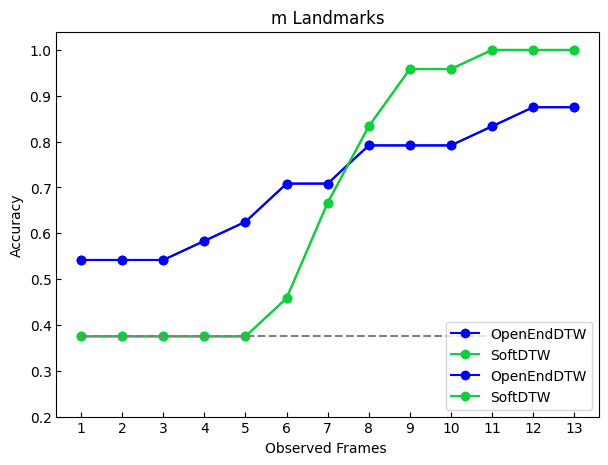

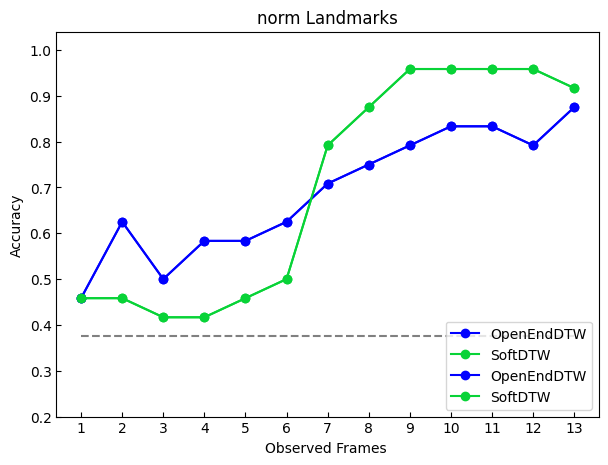

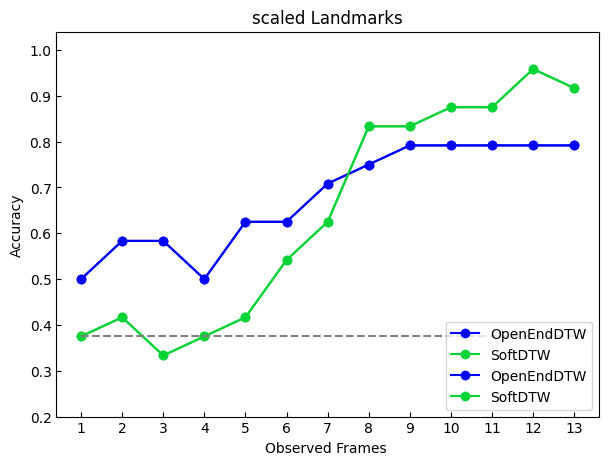

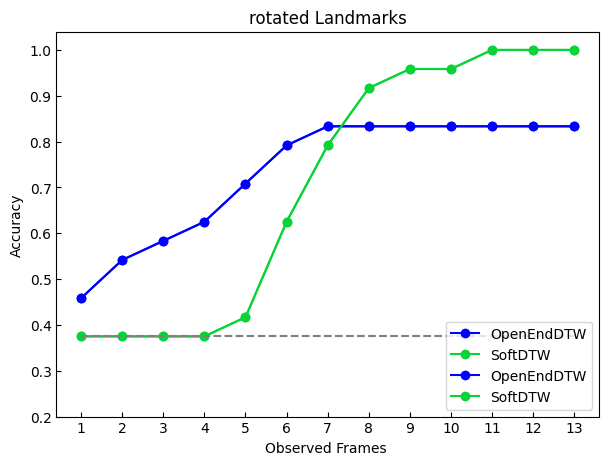

In [32]:
for COORD_TYPE in COORD_TYPES:
    
    plt.figure(figsize=(7,5))
    config = {f'{dtw_var}': {'acc': [results_all[COORD_TYPE][dtw_var]['coords'][r]['acc'] for r in OBS_RATIOS],
                            'color': DTW_COLORS[dtw_var]} for dtw_var in DTW_VARS}

    for label, res in config.items():
        plt.plot(OBS_RATIOS, res['acc'], marker='o', label=label, color=res['color'])

    plt.xlabel(f"Observed Frames {'(%)' if OBS_RATIOS[0] > 1 else ''}")
    plt.ylabel("Accuracy")
    plt.title(f"{COORD_TYPE} Landmarks")
    plt.grid()
    plt.legend(loc='lower right')

    for label, res in config.items():
        plt.plot(OBS_RATIOS, res['acc'], marker='o', label=label, color=res['color'])

    plt.xlabel(f"Observed Frames {'(%)' if OBS_RATIOS[0] > 1 else ''}")
    plt.ylabel("Accuracy")
    plt.title(f"{COORD_TYPE} Landmarks")
    plt.grid()
    plt.legend(loc='lower right')
    plt.xticks(OBS_RATIOS)
    plt.ylim(0.2, 1.04)
    _, yt_n =  np.unique(y_test, return_counts=True)
    plt.hlines(np.max(yt_n)/np.sum(yt_n), OBS_RATIOS[0], OBS_RATIOS[-1], colors='gray', linestyles='dashed', label='Random')
    plt.tick_params(axis='both', direction='in', which='both')
    plt.show()


## DTW Using Primitives

In [33]:
def find_class_prototype(X_train: np.ndarray, y_train: np.ndarray):
    Xtrain_by_class = defaultdict(list)
    prototype_res = {}
    for x, y in zip(X_train, y_train):
        Xtrain_by_class[y].append(x)   
        
    for class_label in Xtrain_by_class.keys():
        #print(f"Class: {class_label}")
        Xtrain_class = np.array(Xtrain_by_class[class_label])
        Xtr_prototype = np.nanmean(Xtrain_class, axis=0) 
        #print(f"Prototype shape: {Xtr_prototype.shape}")
        prototype_res[class_label] = Xtr_prototype
    return prototype_res


In [34]:
PLOTS_DIR = "./outputs/dtw_prim/"

results_all = {f'{lm}': {'OpenEndDTW': {}, 'SoftDTW': {}} for lm in COORD_TYPES}
data_id = 'coords'
metadata_files_all = get_video_metadata(BASE_DIR)

for COORD_TYPE in COORD_TYPES:
    print(f"\n================= Using {COORD_TYPE} coordinates =================")
    all_landmarks = []
    class_labels = []
    
    for gesture_class in ["rock", "paper", "scissors"]:
        metadata_files_class = [f for f in metadata_files_all if f"{os.sep}{gesture_class}{os.sep}" in f]
        #print(f"\n===== Number of {gesture_class} videos: {len(metadata_files_class)} =====")
        with redirect_stdout(f):
            all_class_landmarks, vid_names = get_padded_landmarks(metadata_files_class, CSV_FILE_NAME, 
                                                              cols_to_use=[f"{c}_world_{COORD_TYPE}" for c in ['x', 'y', 'z']])
        all_landmarks.extend(all_class_landmarks)
        class_labels.extend([gesture_class] * len(all_class_landmarks))

    # Randomly split all_landmarks into stratified train and test sets
    X_train, X_test, y_train, y_test = train_test_split(all_landmarks, class_labels, 
                                                        test_size=0.4, random_state=12345, 
                                                        stratify=class_labels)

    # Find class prototypes from training set
    prototypes = find_class_prototype(X_train, y_train)
    
    print(f"Train samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    OBS_RATIOS = list(range(1, len(all_landmarks[0]) + 1))

    # Encode class labels as integers
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)

    for DTW_VAR in DTW_VARS:
        print("\n-----", DTW_VAR, "-----")
        results = {r: {"y_true": [], "y_pred": [], "conf": []} for r in OBS_RATIOS}

        for r in OBS_RATIOS: 
            n_neg_dist = 0
            for sample_idx, (X_test_i, y_test_i) in enumerate(zip(X_test, y_test_enc)):
                n_comp = 0
                T = X_test_i.shape[0]        
                if type(r) is not int: 
                    t_obs = max(1, int(np.round(T * r / 100.0)))
                else:
                    t_obs = min(r, T)
                query = X_test_i[:t_obs].reshape(-1, X_test_i.shape[1]*X_test_i.shape[2])
                #query = X_test_i[:t_obs]
                
                dists = []
                for prot_class_i in prototypes:
                    reference = prototypes[prot_class_i].reshape(-1, prototypes[prot_class_i].shape[1]*prototypes[prot_class_i].shape[2])
                    #reference = prototypes[prot_class_i]
                    y_train_i = np.where(le.classes_ == prot_class_i)[0][0]
                    #with redirect_stdout(f):
                    if DTW_VAR == "OpenEndDTW":
                        c, alignment = run_dtw_variant(DTW_VAR, query, reference, open_begin=False, open_end=True)
                    elif DTW_VAR == "SoftDTW":
                        c, alignment = run_dtw_variant(DTW_VAR, query, reference, gamma=0.5)
                    elif DTW_VAR == "CTW":
                        c, alignment = run_dtw_variant(DTW_VAR, query, reference)
                    n_comp += 1
                    if c<0: 
                        n_neg_dist += 1
                    dists.append((c, y_train_i, alignment))
                
                dists.sort(key=lambda x: x[0])
                y_pred = dists[0][1]
                alignment = dists[0][2]

                if CREATE_PLOTS:
                    if DTW_VAR == "OpenEndDTW":
                        plot_alignment_matrix_oedtw(alignment.cumsum_matrix, alignment.path, 
                                                  f'{DTW_VAR} Alignment Example', 
                                                  le.classes_[y_test_i].item().capitalize(), le.classes_[y_pred].item().capitalize(), 
                                                  save_fig=True, fig_name=f'{DTW_VAR}_obs={r}_sample{sample_idx}')
                    elif DTW_VAR == "SoftDTW":
                        plot_alignment_matrix_softdtw(alignment, f'{DTW_VAR} Alignment Example', 
                                                       le.classes_[y_test_i].item().capitalize(), le.classes_[y_pred].item().capitalize(), 
                                                       cmap='viridis', save_fig=True, fig_name=f'{DTW_VAR}_obs={r}_sample{sample_idx}')


                # margin = distance to 2nd nearest
                conf = dists[1][0] - dists[0][0] if len(dists) > 1 else 0.0
                results[r]["y_true"].append(y_test_i)
                results[r]["y_pred"].append(y_pred)
                results[r]["conf"].append(conf)

            y_true = [i.item() for i in results[r]["y_true"]]
            y_pred = [i.item() for i in results[r]["y_pred"]]
            plot_conf_matrix(y_true, y_pred, r, save_fig=True, cmap='Blues' if DTW_VAR=='OpenEndDTW' else 'Greens', PLOTS_DIR=PLOTS_DIR)
            
            acc = accuracy(results[r]["y_true"], results[r]["y_pred"])
            results[r]["acc"] = acc
            print(f"{r}% observed: {acc:.3f}    (n_neg_dist: {n_neg_dist}/{n_comp})")
            results_all[COORD_TYPE][DTW_VAR][data_id] = results


paper: 19 image directories found.
rock: 22 image directories found.
scissors: 21 image directories found.

================= Using m coordinates =================
Train samples: 35
Test samples: 24

----- OpenEndDTW -----
1% observed: 0.250    (n_neg_dist: 0/3)
2% observed: 0.250    (n_neg_dist: 0/3)
3% observed: 0.250    (n_neg_dist: 0/3)
4% observed: 0.292    (n_neg_dist: 0/3)
5% observed: 0.333    (n_neg_dist: 0/3)
6% observed: 0.458    (n_neg_dist: 0/3)
7% observed: 0.542    (n_neg_dist: 0/3)
8% observed: 0.625    (n_neg_dist: 0/3)
9% observed: 0.667    (n_neg_dist: 0/3)
10% observed: 0.625    (n_neg_dist: 0/3)
11% observed: 0.625    (n_neg_dist: 0/3)
12% observed: 0.583    (n_neg_dist: 0/3)
13% observed: 0.625    (n_neg_dist: 0/3)

----- SoftDTW -----
1% observed: 0.375    (n_neg_dist: 0/3)
2% observed: 0.375    (n_neg_dist: 72/3)
3% observed: 0.375    (n_neg_dist: 72/3)
4% observed: 0.375    (n_neg_dist: 72/3)
5% observed: 0.375    (n_neg_dist: 72/3)
6% observed: 0.417    (n_neg

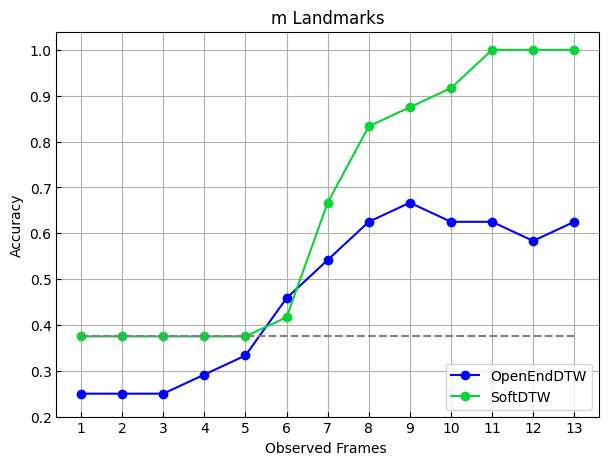

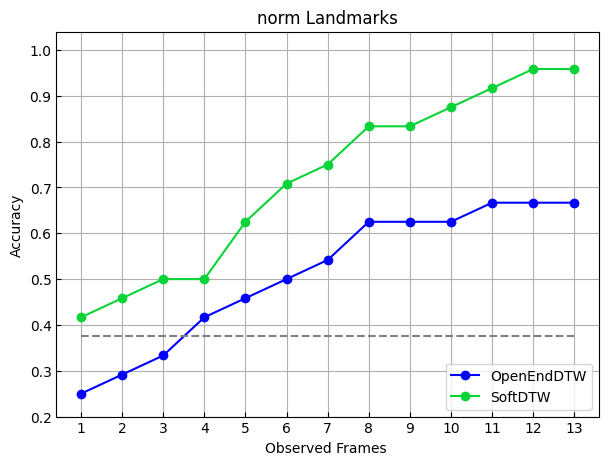

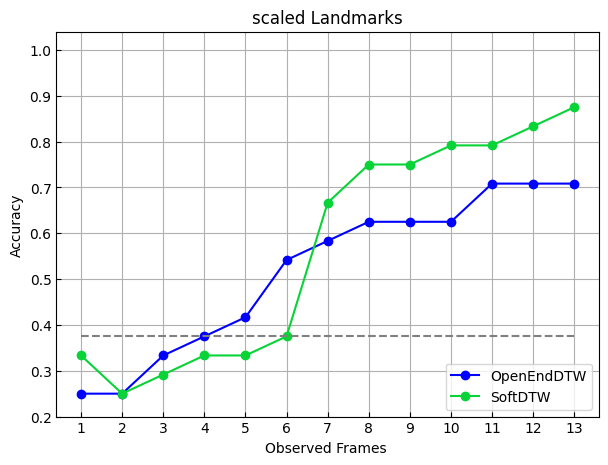

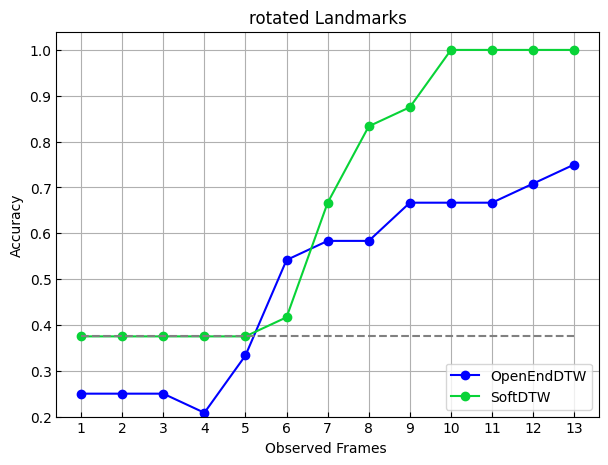

In [35]:
for COORD_TYPE in COORD_TYPES:
    
    plt.figure(figsize=(7,5))
    config = {f'{dtw_var}': {'acc': [results_all[COORD_TYPE][dtw_var]['coords'][r]['acc'] for r in OBS_RATIOS],
                            'color': DTW_COLORS[dtw_var]} for dtw_var in DTW_VARS}

    for label, res in config.items():
        plt.plot(OBS_RATIOS, res['acc'], marker='o', label=label, color=res['color'])

    plt.xlabel(f"Observed Frames {'(%)' if OBS_RATIOS[0] > 1 else ''}")
    plt.ylabel("Accuracy")
    plt.title(f"{COORD_TYPE} Landmarks")
    plt.grid()
    plt.legend(loc='lower right')
    plt.xticks(OBS_RATIOS)
    plt.ylim(0.2, 1.04)
    _, yt_n =  np.unique(y_test, return_counts=True)
    plt.hlines(np.max(yt_n)/np.sum(yt_n), OBS_RATIOS[0], OBS_RATIOS[-1], colors='gray', linestyles='dashed', label='Random')
    plt.tick_params(axis='both', direction='in', which='both')
    plt.show()
